Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    recall_score,
    f1_score,
    precision_score
)
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [199]:
df = pd.read_csv("/Users/sanjayduduka/Desktop/FS_Task02/Cleaned_Customer_Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Read Customer Churn Data

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Remove Customer ID Column

In [201]:
df.drop('customerID', axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Convert Target Variable (Churn)

In [202]:
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

Check Churn Distribution

In [203]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

Identify Categorical Features

In [204]:
cat_cols = df.select_dtypes(
    include='object'
).columns

cat_cols

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Encode Categorical Variables

In [205]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


Create Features and Target

In [206]:
X = df.drop('Churn', axis=1)

y = df['Churn']

Split Data into Train and Test Sets

In [207]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


Define Machine Learning Models

In [208]:

models = {

    "Random Forest": RandomForestClassifier(
        n_estimators=1200,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=3,
        gamma=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2,
        scale_pos_weight=2.8,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42
    )
}

Train and Evaluate Models

In [209]:

results = []

for model_name, model in models.items():

    print(model_name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        model_name,
        acc,
        precision,
        recall,
        f1,
        roc_auc
    ])


    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


Random Forest
Accuracy  : 0.7771
Precision : 0.5732
Recall    : 0.6283
F1 Score  : 0.5995
ROC AUC   : 0.8355

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1035
           1       0.57      0.63      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409


Confusion Matrix:
[[860 175]
 [139 235]]
XGBoost
Accuracy  : 0.7594
Precision : 0.5327
Recall    : 0.7620
F1 Score  : 0.6271
ROC AUC   : 0.8350

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


Confusion Matrix:
[[785 250]
 [ 89 285]]


Compare Model Performance

In [210]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ]
)

results_df = results_df.sort_values(
    by='ROC AUC',
    ascending=False
)

print("\n")

print("MODEL COMPARISON")

results_df




MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.777147,0.573171,0.628342,0.599490,0.835532
1,XGBoost,0.759404,0.532710,0.762032,0.627063,0.834952


Select Best Performing Model

In [211]:
best_model = results_df.iloc[0]

print("\nBest Model:")
print(f"Model   : {best_model['Model']}")
print(f"ROC AUC : {best_model['ROC AUC']:.4f}")


Best Model:
Model   : Random Forest
ROC AUC : 0.8355


Define Hyperparameter Search Space

In [212]:

param_grid = {
    'n_estimators': [500, 800, 1000, 1200, 1500],
    'max_depth': [10, 15, 20, 25, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

Perform Hyperparameter Tuning

In [213]:
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest ROC-AUC:")
print(rf_search.best_score_)

best_rf = rf_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1200; total time=   6.4s
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1200; total time=   6.6s
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1200; total time=   6.7s
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1200; total time=   6.7s
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=15, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=1200; total time=   6.8s
[CV] END bootstrap=False, class_weight=balanced_subsample, max_depth=None, max_features=

View Best Parameters

In [214]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest ROC AUC:")
print(rf_search.best_score_)

Best Parameters:
{'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced_subsample', 'bootstrap': True}

Best ROC AUC:
0.8453240893697437


Retrieve Optimized Model

In [215]:
best_rf = rf_search.best_estimator_

best_rf

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       max_features='log2', min_samples_leaf=4,
                       min_samples_split=5, n_estimators=800, n_jobs=-1,
                       random_state=42)

Generate Predictions

In [216]:
y_pred = best_rf.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0])

Calculate Prediction Probabilities

In [217]:
y_probability = best_rf.predict_proba(X_test)[:, 1]
y_probability

array([0.01907784, 0.84295519, 0.10892076, ..., 0.23783034, 0.09512515,
       0.0335363 ])

Evaluate Final Model

In [218]:

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7686302342086586
Precision: 0.5474308300395256
Recall   : 0.7406417112299465
F1 Score : 0.6295454545454545
ROC AUC  : 0.8349518199901832

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409


Confusion Matrix
[[806 229]
 [ 97 277]]


Plot ROC Curve

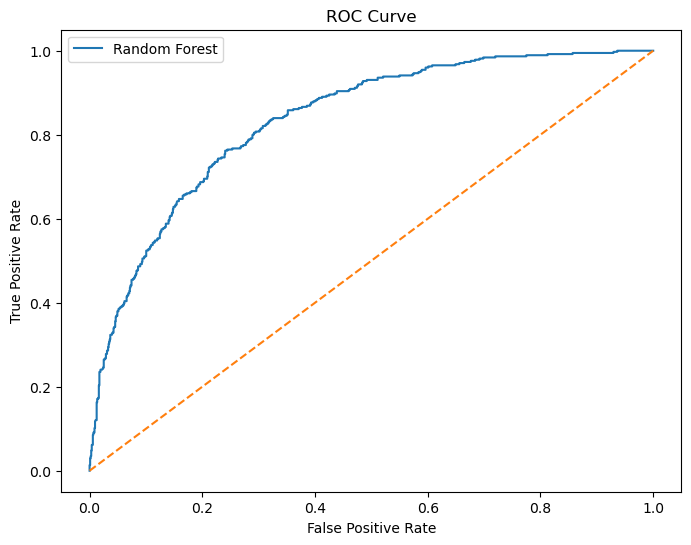

In [222]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

Display Confusion Matrix

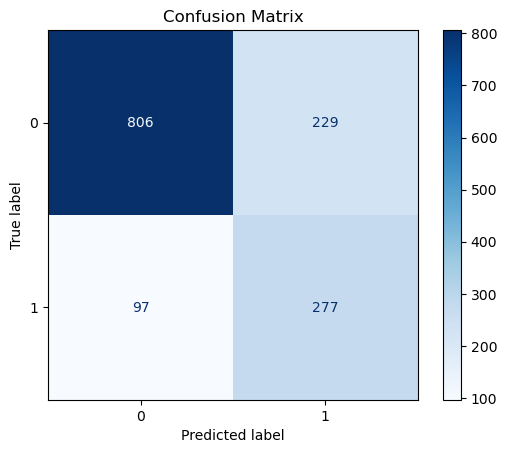

In [223]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.show()

Calculate Feature Importance

In [224]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
14,Contract,0.188737
4,tenure,0.150307
18,TotalCharges,0.121295
17,MonthlyCharges,0.117088
8,OnlineSecurity,0.087717
11,TechSupport,0.073355
7,InternetService,0.051837
16,PaymentMethod,0.040761
9,OnlineBackup,0.033858
15,PaperlessBilling,0.021445


Visualize Feature Importance

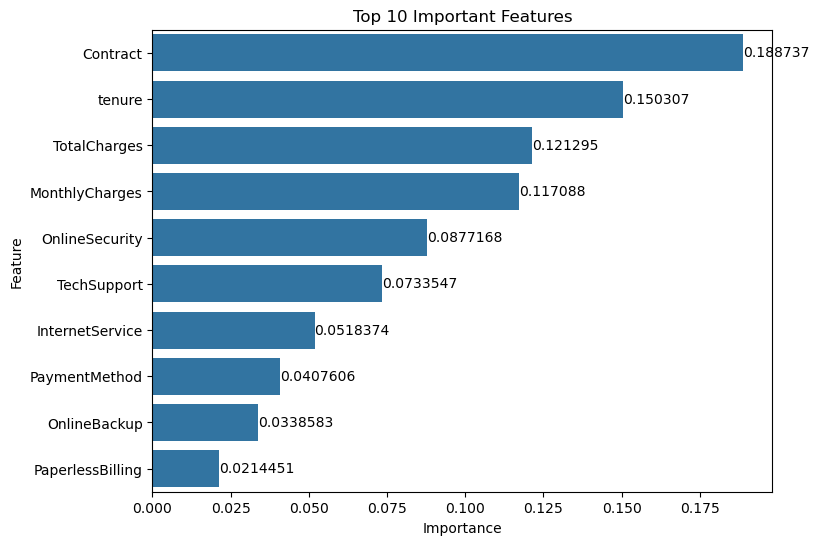

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

x=sns.barplot(
    data=importance_df.head(10),
    x='Importance',
    y='Feature'
)
for i in x.containers:
    x.bar_label(i)

plt.title('Top 10 Important Features')
plt.show()

Import SHAP Library

In [226]:
import shap


Create SHAP Explainer

In [227]:
explainer = shap.TreeExplainer(best_rf)
explainer

Generate SHAP Values

In [228]:
shap_values = explainer.shap_values(X_test)


Plot SHAP Summary 

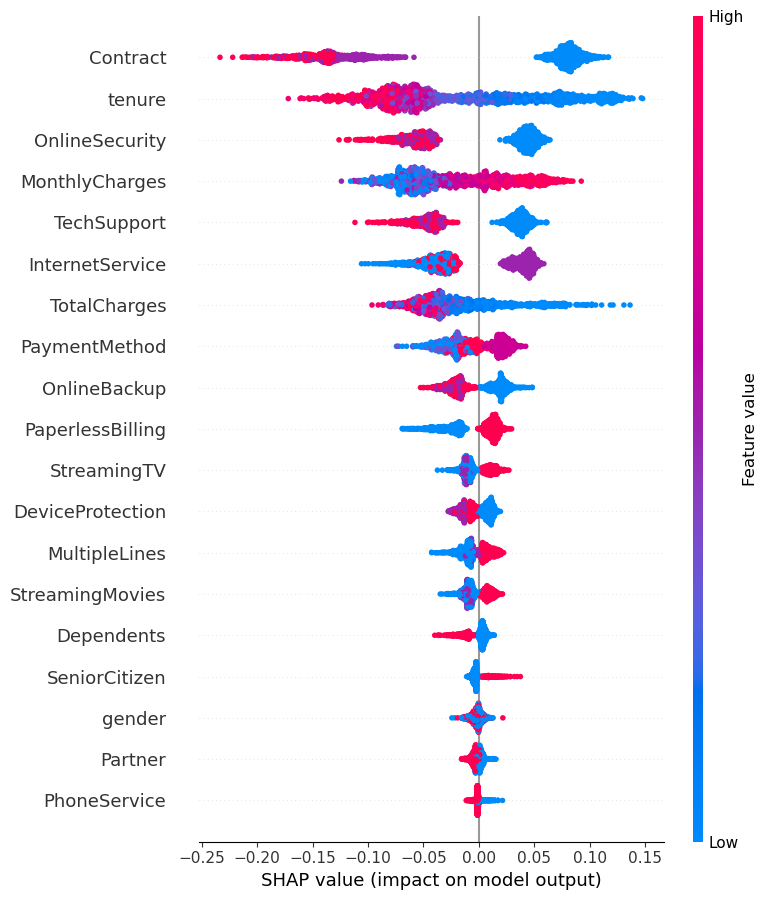

In [229]:
shap.summary_plot(
    shap_values[:,:,1] if len(shap_values.shape)==3 else shap_values,
    X_test
)

Explain Individual Prediction

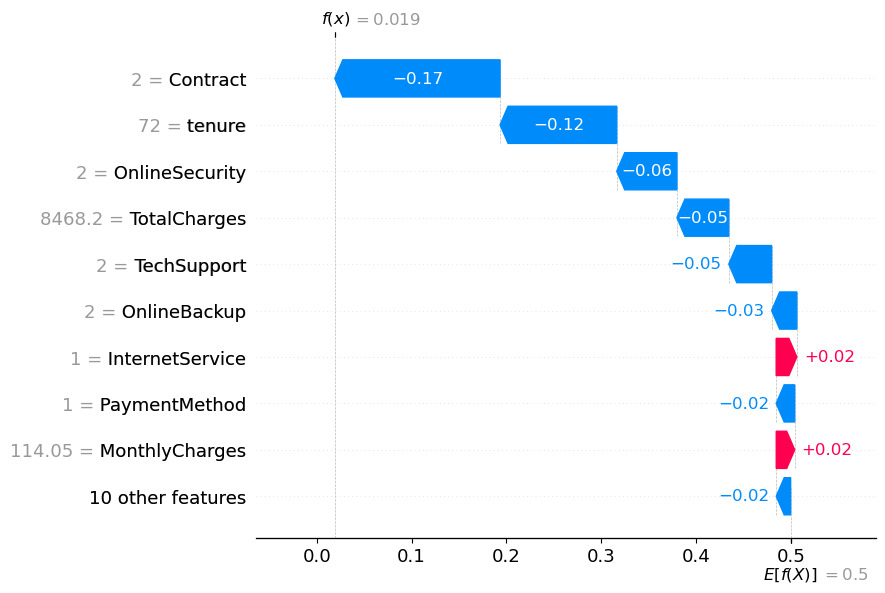

In [ ]:
import shap

explainer = shap.TreeExplainer(best_rf)

shap_values = explainer(X_test)
sample_idx = 0
class_idx = 1 

sample_exp = shap.Explanation(
    values=shap_values.values[sample_idx, :, class_idx],
    base_values=shap_values.base_values[sample_idx, class_idx],
    data=shap_values.data[sample_idx],
    feature_names=X_test.columns
)

shap.plots.waterfall(sample_exp)

Retraining Model with Top 10 Features

Select Top 10 Important Features

In [247]:
top_features = [
    'Contract',
    'tenure',
    'TotalCharges',
    'MonthlyCharges',
    'OnlineSecurity',
    'TechSupport',
    'InternetService',
    'PaymentMethod',
    'OnlineBackup',
    'PaperlessBilling'
]

X = df[top_features]
y = df['Churn']

Train Model Using Top Features

In [256]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

best_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=500, n_jobs=-1, random_state=42)

Generate New Predictions

In [257]:
pred=best_rf.predict(X_test)
pred

array([0, 1, 0, ..., 0, 0, 0])

Evaluate Retrained Model

In [258]:
print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report")
print(classification_report(y_test, pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, pred))

Accuracy : 0.7735982966643009
Precision: 0.5638051044083526
Recall   : 0.6497326203208557
F1 Score : 0.6037267080745342
ROC AUC  : 0.8349518199901832

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.56      0.65      0.60       374

    accuracy                           0.77      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.79      0.77      0.78      1409


Confusion Matrix
[[847 188]
 [131 243]]


Save Trained Model

In [249]:
import joblib

joblib.dump(best_rf, "data/TeleCustomer_Churn_Model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [250]:
import joblib

model = joblib.load("data/TeleCustomer_Churn_Model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


In [251]:
import os

print(os.path.exists("data/TeleCustomer_Churn_Model.pkl"))

True


In [252]:
import joblib
import os

joblib.dump(best_rf, "TeleCustomer_Churn_Model.pkl")

print("Saved:", os.path.exists("TeleCustomer_Churn_Model.pkl"))

Saved: True


Load Final Saved Model

In [253]:
import joblib

model = joblib.load("TeleCustomer_Churn_Model.pkl")

* Customer Churn Prediction Model
This project focuses on predicting customer churn using machine learning techniques. The workflow includes data preprocessing, feature encoding, model training, performance evaluation, hyperparameter tuning, feature importance analysis, and model interpretation using SHAP. Multiple classification algorithms are compared to identify the best-performing model. The selected model is further optimized and retrained using the top 10 most important features to improve efficiency while maintaining strong predictive performance. Finally, the trained model is saved and loaded for future deployment and real-world churn prediction applications.